In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

from abc import ABC, abstractmethod
from typing import List, Tuple

class Problem(ABC):
    @abstractmethod
    def initial_state(self):
        pass

    @abstractmethod
    def is_goal(self, state):
        pass

    @abstractmethod
    def actions(self, state):
        pass

    @abstractmethod
    def result(self, state, action):
        pass

    @abstractmethod
    def action_cost(self, state, action, next_state):
        pass

class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):

        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
          return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        row, col = state
        legal_actions = []
        for action, move in MOVES.items():
            new_row, new_col = row + move[0], col + move[1]
            if self.in_bounds((new_row, new_col)) and self.is_free((new_row, new_col)):
                legal_actions.append(action)
        return legal_actions


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(self, state: Tuple[int, int], action: str,
       next_state: Tuple[int, int],) -> float:
        return 1
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
    ]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [3]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [4]:
from abc import ABC
from dataclasses import dataclass
from typing import Any, Iterable, Optional, List, Dict

@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional["Node"] = None
    nodes_expanded: int = 0
    max_frontier_size: int = 0
    iteration_log: Optional[List[Dict]] = None
    reached_count: int = 0
    limit: Optional[int] = None

@dataclass(frozen=True)
class Node:
    state: Any
    parent: Optional["Node"]
    action: Optional[str]
    path_cost: float
    depth: int = 0

    def __post_init__(self):
        if self.parent:
            object.__setattr__(self, 'depth', self.parent.depth + 1)

class SearchAlgorithm(ABC):

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
      s = node.state
      for action in problem.actions(s):
        s_prime = problem.result(s, action)
        cost = node.path_cost + problem.action_cost(s, action, s_prime)

        yield Node(state=s_prime, parent=node,
                   action=action, path_cost=cost)

def state_is_on_path(node: Node, state_to_check: Any) -> bool:
    current = node
    while current:
        if current.state == state_to_check:
            return True
        current = current.parent
    return False

In [5]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        nodes_expanded = 0
        max_frontier_size = 0


        initial_node = Node(state=problem.initial_state(), parent=None, action=None, path_cost=0.0)
        if problem.is_goal(initial_node.state):
          return SearchResult(algorithm, "success", initial_node)

        frontier= deque([initial_node])
        reached = {initial_node.state}

        while frontier:
          initial_node = frontier.popleft()
          nodes_expanded += 1
          for child in self.expand(problem, initial_node):
                if problem.is_goal(child.state):
                        return SearchResult(algorithm, "success", child)
                if child.state not in reached:
                      reached.add(child.state)
                      frontier.append(child)
          max_frontier_size = max(max_frontier_size, len(frontier))

          return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))

In [6]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 0

        node = Node(state=problem.initial_state(), parent=None, action=None, path_cost=0.0)
        if problem.is_goal(node.state):
            return SearchResult(algorithm, "success", node)

        frontier = [node]
        reached ={node.state}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                   if problem.is_goal(child.state):
                            return SearchResult(algorithm, "success", child, nodes_expanded,
                                                max_frontier_size, len(reached))
                   if child.state not in reached:
                        reached.add(child.state)
                        frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))

In [7]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state(), parent=None, action=None, path_cost=0.0)

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(self, problem: Problem,node: Node,
        limit: int, metrics: Dict[str, int],
        current_stack_size: int,) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return (node, "success")

        elif node.depth >= limit:
            return (None, "cutoff")

        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False

            for child in self.expand(problem, node):
              if state_is_on_path(node, child.state):
                continue
              metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)

              result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size + 1)
              if status == "success":
                return (result, "success")
              elif status == "cutoff":
                cutoff_occurred = True

            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")

In [8]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size = 0

        for limit in range(max_depth):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)
            iteration_log.append(
                {
                    "depth": limit,
                    "nodes_expanded": result.nodes_expanded,
                    "max_stack_size": result.max_frontier_size,
                }
            )
            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)
            if result.status == "success":
              return SearchResult(
                  algorithm=algorithm,
                  status="success",
                  solution=result.solution,
                  nodes_expanded=total_nodes_expanded,
                  max_frontier_size=max_stack_size,
                  iteration_log=iteration_log,
              )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iteration_log=iteration_log,
                )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            iteration_log=iteration_log,
        )
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

Algorithm       Status     Nodes Expanded     Max Frontier Size    Path Cost    Depth   
-------------------------------------------------------------------------------------
BFS             failure    1                  1                    N/A          N/A     
DFS             success    18                 4                    18.00        18      
DLS             cutoff     16                 11                   N/A          N/A     
IDS             success    356                19                   18.00        18      
  Iteration Log:
    Depth 0: Nodes Expanded=0, Max Stack Size=1
    Depth 1: Nodes Expanded=1, Max Stack Size=2
    Depth 2: Nodes Expanded=2, Max Stack Size=3
    Depth 3: Nodes Expanded=3, Max Stack Size=4
    Depth 4: Nodes Expanded=4, Max Stack Size=5
    Depth 5: Nodes Expanded=5, Max Stack Size=6
    Depth 6: Nodes Expanded=6, Max Stack Size=7
    Depth 7: Nodes Expanded=8, Max Stack Size=8
    Depth 8: Nodes Expanded=10, Max Stack Size=9
    Depth 9: Nodes 

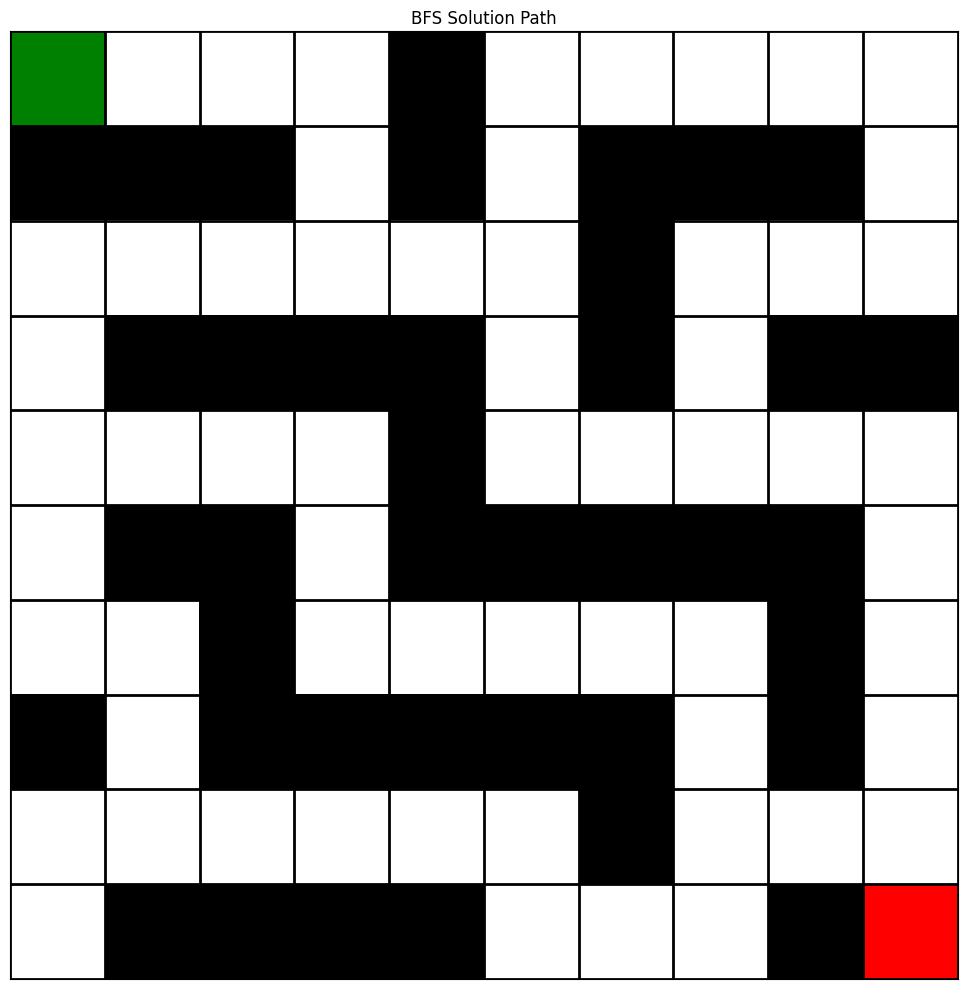

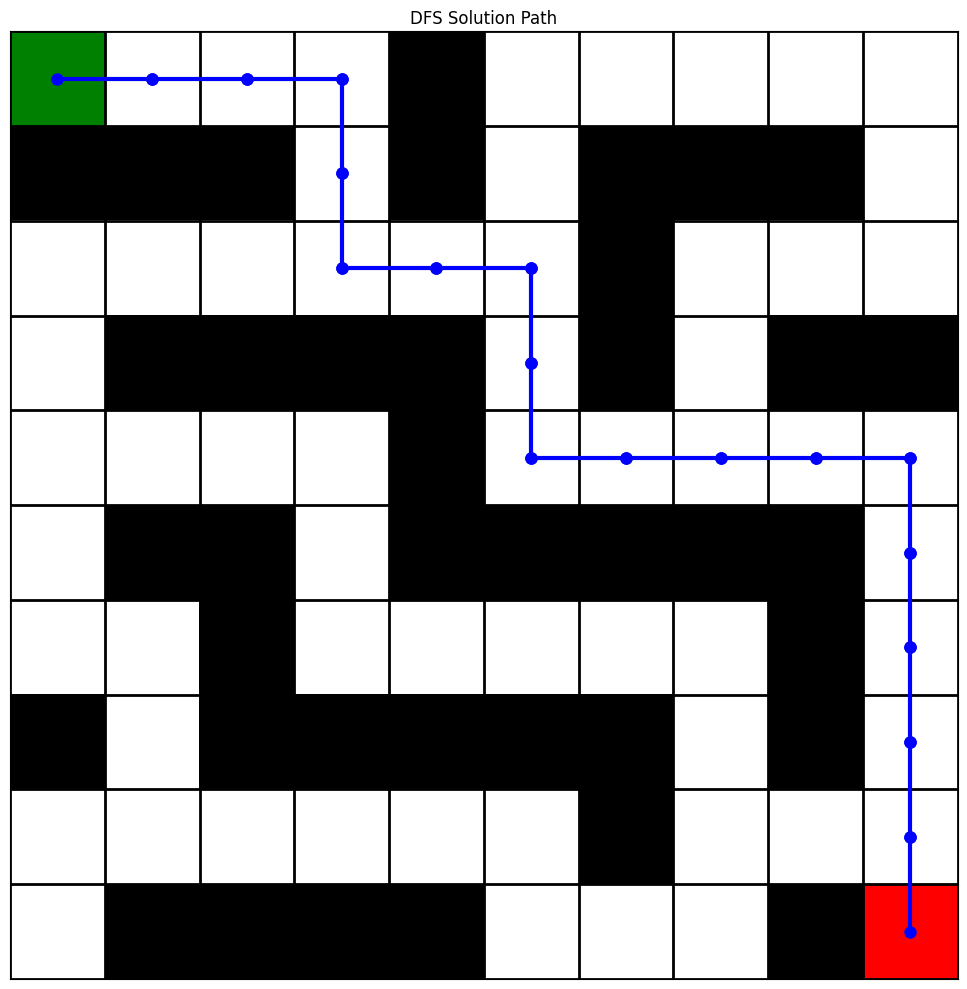

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_results(results: List[SearchResult]):
    print(f"{'Algorithm':<15} {'Status':<10} {'Nodes Expanded':<18} {'Max Frontier Size':<20} {'Path Cost':<12} {'Depth':<8}")
    print("-" * 85)
    for res in results:
        path_cost = f"{res.solution.path_cost:.2f}" if res.solution else 'N/A'
        depth = str(res.solution.depth) if res.solution else 'N/A'
        print(f"{res.algorithm:<15} {res.status:<10} {res.nodes_expanded:<18} {res.max_frontier_size:<20} {path_cost:<12} {depth:<8}")
    if res.iteration_log:
            print("  Iteration Log:")
            for log_entry in res.iteration_log:
                print(f"    Depth {log_entry['depth']}: Nodes Expanded={log_entry['nodes_expanded']}, Max Stack Size={log_entry['max_stack_size']}")

def plot_path(grid: List[List[int]], start: Tuple[int, int], goal: Tuple[int, int], solution_node: Optional[Node], title: str = ""):
    rows = len(grid)
    cols = len(grid[0])

    fig, ax = plt.subplots(figsize=(cols, rows))
    ax.imshow(grid, cmap='Greys', origin='upper')

    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
    ax.tick_params(which='minor', size=0)
    ax.tick_params(which='major', bottom=False, left=False, labelbottom=False, labelleft=False)

    ax.add_patch(patches.Rectangle((start[1]-0.5, start[0]-0.5), 1, 1, facecolor='green', edgecolor='black', linewidth=1))
    ax.add_patch(patches.Rectangle((goal[1]-0.5, goal[0]-0.5), 1, 1, facecolor='red', edgecolor='black', linewidth=1))

    path_states = []
    if solution_node:
        current = solution_node
        while current:
            path_states.append(current.state)
            current = current.parent
        path_states.reverse()

        if len(path_states) > 1:
            for i in range(len(path_states) - 1):
                y1, x1 = path_states[i]
                y2, x2 = path_states[i+1]
                ax.plot([x1, x2], [y1, y2], color='blue', linewidth=3, marker='o', markersize=8)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    solution_node=bfs_result.solution,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    solution_node=dfs_result.solution,
    title="DFS Solution Path",
)

In [10]:
custom_grid_1 = [
    [0,0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,0,1,1,1,1,0],
    [0,0,0,0,1,0,1,0,0,1,0],
    [0,1,1,0,1,0,1,0,1,1,0],
    [0,0,1,0,1,0,1,0,1,0,0],
    [1,0,1,0,1,0,1,0,1,0,1],
    [0,0,1,0,1,0,1,0,1,0,0],
    [0,1,1,0,1,1,1,0,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (8,9)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=40),
     ids.search(custom_problem_1, max_depth=40),
 ]
show_results(custom_results_1)

Algorithm       Status     Nodes Expanded     Max Frontier Size    Path Cost    Depth   
-------------------------------------------------------------------------------------
BFS             failure    1                  1                    N/A          N/A     
DFS             success    21                 2                    21.00        21      
DLS             success    27                 22                   21.00        21      
IDS             success    306                22                   21.00        21      
  Iteration Log:
    Depth 0: Nodes Expanded=0, Max Stack Size=1
    Depth 1: Nodes Expanded=1, Max Stack Size=2
    Depth 2: Nodes Expanded=2, Max Stack Size=3
    Depth 3: Nodes Expanded=3, Max Stack Size=4
    Depth 4: Nodes Expanded=4, Max Stack Size=5
    Depth 5: Nodes Expanded=5, Max Stack Size=6
    Depth 6: Nodes Expanded=6, Max Stack Size=7
    Depth 7: Nodes Expanded=8, Max Stack Size=8
    Depth 8: Nodes Expanded=10, Max Stack Size=9
    Depth 9: Nodes 

Interpretation
All successful algorithms had a path cost of 21. Out of the 3, DFS expanded the fewest nodes amking it more efficient. BFS failed. IDS found the same solution but expanded quite a bit more nodes. DLS was also efficient but expanded a bit more nodes that DFS.

In [11]:
custom_grid_2 = [
   [0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0],
   [0,1,1,1,0,1,0,1,0,0,1,1,0,1,1,1,1,0,0,0],
   [0,0,0,1,0,0,0,0,0,0,1,1,1,1,0,1,0,0,0,0],
   [0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0],
   [0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,0,0,0],
   [0,1,1,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0],
   [0,0,0,0,0,1,1,0,0,1,1,1,0,0,1,0,1,0,1,0],
   [0,1,1,1,0,1,1,1,0,0,1,0,0,0,0,1,0,1,1,1],
   [1,1,0,0,0,1,0,0,1,1,1,1,1,0,1,0,0,0,0,0],
   [0,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1],
   [0,0,0,0,0,0,1,0,1,0,0,1,1,1,0,0,0,0,0,0],
   [0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1],
   [1,0,0,0,0,1,1,0,0,1,1,1,1,1,1,1,0,0,0,1],
   [0,1,1,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0],
   [0,0,1,1,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0],
   [1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0],
   [0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0],
   [0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0],
   [0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
   [0,1,0,0,0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0],
]

custom_start_2 = (0,3)
custom_goal_2 = (10,10)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=40),
     ids.search(custom_problem_2, max_depth=40),
 ]
show_results(custom_results_2)

Algorithm       Status     Nodes Expanded     Max Frontier Size    Path Cost    Depth   
-------------------------------------------------------------------------------------
BFS             failure    1                  2                    N/A          N/A     
DFS             success    160                50                   73.00        73      
DLS             success    30147              41                   39.00        39      
IDS             success    131876             28                   27.00        27      
  Iteration Log:
    Depth 0: Nodes Expanded=0, Max Stack Size=1
    Depth 1: Nodes Expanded=1, Max Stack Size=2
    Depth 2: Nodes Expanded=3, Max Stack Size=3
    Depth 3: Nodes Expanded=5, Max Stack Size=4
    Depth 4: Nodes Expanded=7, Max Stack Size=5
    Depth 5: Nodes Expanded=10, Max Stack Size=6
    Depth 6: Nodes Expanded=15, Max Stack Size=7
    Depth 7: Nodes Expanded=26, Max Stack Size=8
    Depth 8: Nodes Expanded=44, Max Stack Size=9
    Depth 9: Nod

Interpretation
This is a 20 x 20 grid containing many obstacles. BFS failed. DFS explores deeply and may find a solution quickly without guaranteed optimality. DLS performs well with a better depth limit, and IDS guarantees optimality at a cost of repeated iterations.

**REFLECTION QUESTIONS**
Section 15.1
1. The state is a tuple of rows and columns describing the drone's current position on the grid.
2. An action is the direction the drone can move in at its current position, that is, left, right, up and down.
3. It takes the drone's current state and action and returns the new position the drone will be in after an action.
4. Separating the problem definition from the search algorithm makes it easier to apply the search algorithm to a different problem and also to use different search algorithms on the same problem.

Section 15.2
1. BFS uses FIFO queue because it explores nodes in order of increasing depth. It adds nodes to the back of the queue and processes the ones in front first.
2. Because it explores all nodes at a depth before moving on to the next.
3. The reached set in BFS keeps track of states the drone has visited to prevent redundancy.

Section 15.3
1. DFS uses a stack because LIFO ensures that the recently added node is explored first.
2.  No. DFS is not guaranteed to find the shortest path. Because it explores each node to depth, creating a long path to the goal even if there was a shorter one.
3. DFS uses less memory if BFS has a wider depth.
4. i. If the the DFS picks the wrong branch to explore first.
ii. If the state space has cycles or an infinite depth.

Section 15.4
1. When the depth limit is too small, DLS cannot reach the goal beacause the search was stopped at the depth limit.
2. Cutoff means that the search reached the depth limit without finding a solution, proving failure, which means no solution exists within the space that has been explored.
3. DLS is DFS with a maximum depth limit. DFS has no restriction, but DLS stops exploring a branch once it reaches its depth limit.
4. In DLS, path-cycle checking is used instead of global reached state because a global reached set would track a state as already visited, preventing the DLS from revisiting that state at greater depth.

Section 15.5
1. IDS repeats DLS with increasing depth limits because how deep the goal is is unknown, so it tries each limit.
2. IDS is complete because it keeps increasing the depth limit until finds a solution or no solution. It tries each limit, and eventually the limit will reach the depth of the goal.
3. IDS uses less memory than BFS because it uses memory similar to DFS. DFS stores only the nodes at the current path where as BFS stores all nodes at the current level.
4. The cost of repeatedly searching from the root is small because most of the search happens at a the deepest level which has more nodes.

Section 15.6
1. A route with good weather condition, less restricted or dangerous zones, good signal, less risk areas and less time consumption.
2. I would choose BFS because BFS is guaranteed to find the path with the fewest number of steps.
3. I would choose DLS because it is designed to restrict how deep the search goes by setting a maximum depth limit.
4. i. A real drone operates in a 3D environment where as the model is 2D.
ii. In the model, the drone can move in only four directions, while a real drone can move in any direction, even diagonally.
iii. The drone in the model knows the environment, but a real drone has limited information about its environment.
iv. The grid model is static, but the real environment is not.